# Legal NLP Model Evaluation: Gemma-2-9B-IT vs. Claude Ground Truth

Evaluates Gemma-2-9B-IT extraction against Claude ground truth using:
- **Exact Match Accuracy** (categorical fields)
- **Token F1 Score** (text overlap)
- **ROUGE-1 / ROUGE-2 / ROUGE-L** (reasoning n-gram overlap)
- **BERTScore** (reasoning semantic similarity)

In [1]:
# Uncomment to install (first time only):
# !pip install pandas rouge-score bert-score scikit-learn matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from bert_score import score
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("husl", 8)

/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import subprocess
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

Wed Jun 24 17:56:22 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090         On | 00000000:3B:00.0 Off |                  N/A |
| 50%   56C    P8               26W / 350W|  21552MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [4]:
!kill 7619

/bin/bash: line 0: kill: (7619) - No such process


## 1. Data Loading & Preprocessing
Loading Claude ground truth and Gemma predictions, merging on `case_id`.

In [3]:
# Load Datasets
claude = pd.read_excel("enriched_legal_records.xlsx")
gemma = pd.read_excel("indilex_extracted_output_Gemma.xlsx")

# Standardize Claude columns
claude = claude.rename(columns={
    "CASE ID": "case_id",
    "LANGUAGE": "language",
    "CASE TYPE": "case_type",
    "JUDGMENT TEXT": "judgment_text",
    "SUBJECT": "subject",
    "OBJECT": "object",
    "OBJECTIVE ASPECT": "objective_aspect",
    "SUBJECTIVE ASPECT": "subjective_aspect",
    "LEGAL PROVISIONS": "legal_provisions",
    "REASONING": "reasoning"
})

# Merge
df = pd.merge(claude, gemma, on="case_id", suffixes=("_gt", "_pred"))
print(f"Ground truth rows: {len(claude)}")
print(f"Gemma prediction rows: {len(gemma)}")
print(f"Merged (matched) rows: {len(df)}")

# Handle missing values
reasoning_missing = df["reasoning_pred"].isna().sum()
if reasoning_missing > 0:
    print(f"WARNING: {reasoning_missing} rows have missing reasoning_pred")
    df["reasoning_pred"] = df["reasoning_pred"].fillna("")

for col in df.columns:
    if col.endswith("_gt") or col.endswith("_pred"):
        df[col] = df[col].fillna("Unknown")

df.head()

Ground truth rows: 4
Gemma prediction rows: 4
Merged (matched) rows: 4


,case_id,language_gt,case_type_gt,judgment_text_gt,subject_gt,object_gt,objective_aspect_gt,subjective_aspect_gt,legal_provisions,reasoning_gt,...,case_type_pred,subject_pred,object_pred,objective_aspect_pred,subjective_aspect_pred,reasoning_pred,raw_output,parse_ok,attempts,error
0,ALL_CRIM_000001,Hindi,Criminal,Application U/S 482 CrPC No. 741 of 2024. Appl...,Dinesh Yadav @ Dinesh Kumar And 7 Others,Wife/Complainant,Assault; Bigamy; Cruelty; Intentional Insult; ...,Dowry Demand,• CrPC Section 482\n• IPC Section 323\n• IPC S...,The legal issue before the court was whether c...,...,Criminal,Dinesh Yadav @ Dinesh Kumar And 7 Others,State/Society,Nullification Of FIR; Quashing Of Chargesheet;...,Settlement Between Parties,The legal issue was whether the criminal case ...,"```json\n{\n""case_type"": ""Criminal"",\n""subject...",True,1,NaN
1,ALL_CRIM_000002,Hindi,Criminal,Criminal Misc. Anticipatory Bail Application U...,Kamlesh Jaiswal Alias Monu Jaiswal And Another,State/Society,Criminal Law Amendment Act Offence,Not Clearly Specified,• CrPC Section 438\n• IPC Section 302\n• IPC S...,The legal issue was whether anticipatory bail ...,...,Criminal,Kamlesh Jaiswal Alias Monu Jaiswal And Another,State/Society,"Section 18 14, 572: 303. 41, 44 IPC and Sectio...",False Implication,The legal issue was whether the applicants wer...,"```json\n{\n""case_type"": ""Criminal"",\n""subject...",True,1,NaN
2,ALL_CRIM_000003,Hindi,Criminal,Application U/S 482 CrPC No. 51 of 2024. Appli...,Bahal Khan And 4 Others,Complainant/Informant,Rioting; Rioting With Deadly Weapon; Assault; ...,Intent/Knowledge To Cause Death Or Serious Harm,• CrPC Section 482\n• IPC Section 147\n• IPC S...,The legal issue was whether an FIR and consequ...,...,Criminal,Bahal Khan And 4 Others,State/Society,Assault; Grievous Hurt; Rioting; Weapon Use,Settlement Agreement,The legal issue was whether the criminal case ...,"{""case_type"": ""Criminal"", ""subject"": ""Bahal Kh...",True,1,NaN
3,ALL_CRIM_000004,Hindi,Criminal,Application U/S 482 CrPC No. 12742 of 2023. Ap...,Banshi Lal,Complainant/Informant,Kidnapping Or Abduction,Intent To Compel Wrongful Restraint/Confinement,• CrPC Section 164\n• CrPC Section 482\n• IPC ...,The legal issue was whether orders accepting t...,...,Criminal,Banshi Lal,State/Society,Kidnapping Or Abduction; False Complaint,Challenge to Final Report,The legal issue was whether the impugned order...,"{""case_type"": ""Criminal"", ""subject"": ""Banshi L...",True,1,NaN


## 2. Exact Match Evaluation
Case-insensitive exact match for categorical fields.

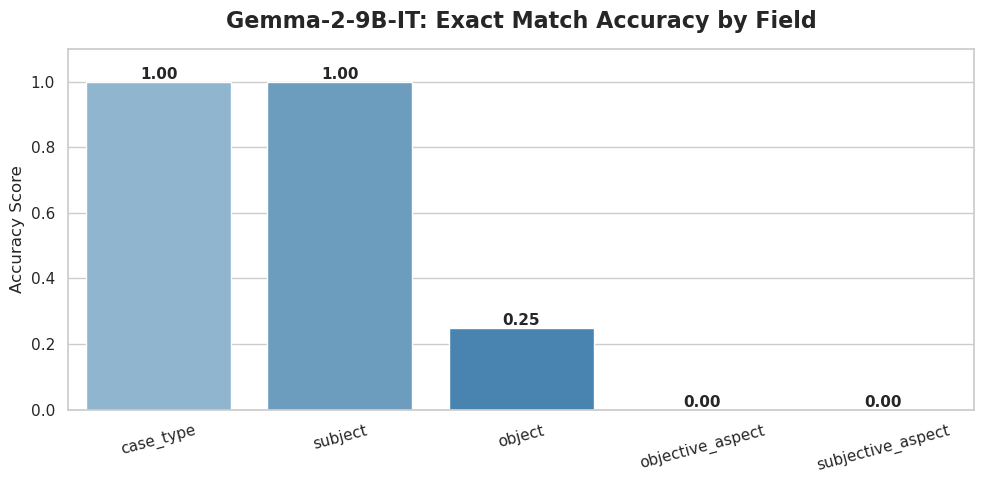

In [4]:
fields_em = ["case_type", "subject", "object", "objective_aspect", "subjective_aspect"]
em_scores = {}

for field in fields_em:
    acc = (
        df[f"{field}_gt"].astype(str).str.lower().str.strip() 
        == 
        df[f"{field}_pred"].astype(str).str.lower().str.strip()
    ).mean()
    em_scores[field] = acc

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(em_scores.keys()), y=list(em_scores.values()), palette="Blues_d")
plt.title("Gemma-2-9B-IT: Exact Match Accuracy by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Token F1 Score Evaluation
Word-level overlap between prediction and ground truth.

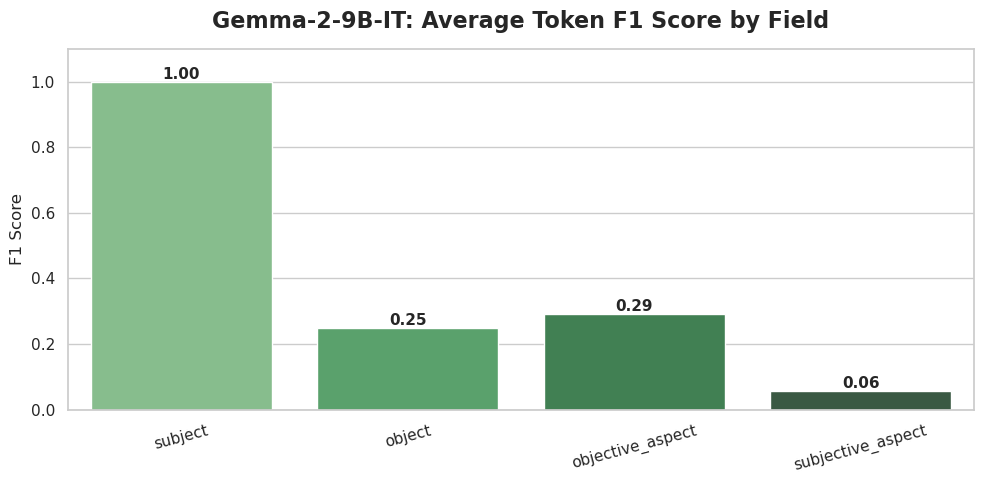

In [5]:
def token_f1(gt, pred):
    gt_tokens = set(str(gt).lower().split())
    pred_tokens = set(str(pred).lower().split())
    
    tp = len(gt_tokens.intersection(pred_tokens))
    precision = tp / max(len(pred_tokens), 1)
    recall = tp / max(len(gt_tokens), 1)
    
    if precision + recall == 0:
        return 0
    return (2 * precision * recall) / (precision + recall)

fields_f1 = ["subject", "object", "objective_aspect", "subjective_aspect"]
f1_scores = {}

for field in fields_f1:
    scores_list = [token_f1(row[f"{field}_gt"], row[f"{field}_pred"]) for _, row in df.iterrows()]
    f1_scores[field] = np.mean(scores_list)

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="Greens_d")
plt.title("Gemma-2-9B-IT: Average Token F1 Score by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. NLP Generation Metrics (Reasoning)
ROUGE for n-gram overlap, BERTScore for semantic similarity.

ROUGE computed on 4 reasoning pairs


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


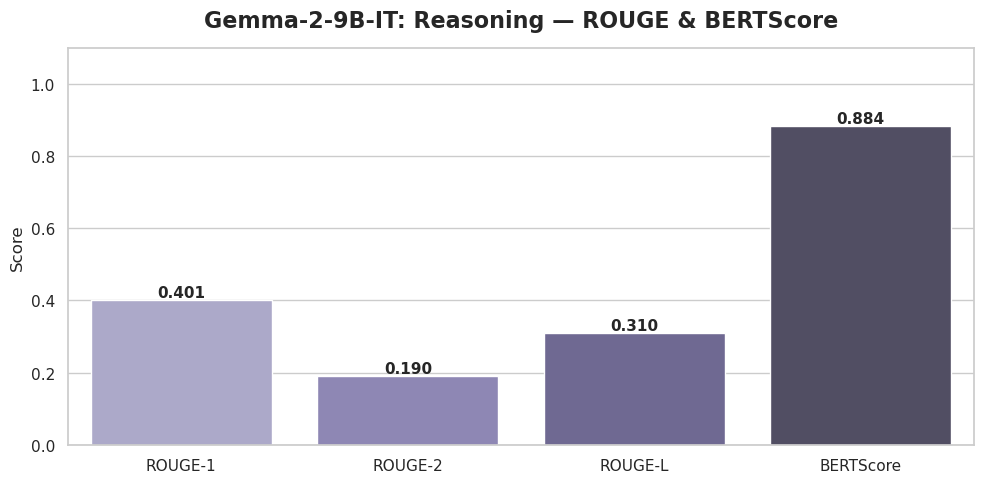

In [6]:
# 1. ROUGE Scores
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rl = [], [], []

for _, row in df.iterrows():
    gt = str(row["reasoning_gt"]).strip()
    pred = str(row["reasoning_pred"]).strip()
    if gt in ("", "nan", "Unknown") and pred in ("", "nan", "Unknown"):
        continue
    if gt in ("", "nan", "Unknown"):
        gt = "No reasoning provided."
    if pred in ("", "nan", "Unknown"):
        pred = "No reasoning provided."
    score_dict = scorer.score(gt, pred)
    r1.append(score_dict["rouge1"].fmeasure)
    r2.append(score_dict["rouge2"].fmeasure)
    rl.append(score_dict["rougeL"].fmeasure)

rouge_results = {
    "ROUGE-1": np.mean(r1) if r1 else 0.0,
    "ROUGE-2": np.mean(r2) if r2 else 0.0,
    "ROUGE-L": np.mean(rl) if rl else 0.0
}
print(f"ROUGE computed on {len(r1)} reasoning pairs")

# 2. BERTScore
predictions = df["reasoning_pred"].astype(str).tolist()
references = df["reasoning_gt"].astype(str).tolist()

P, R, F1 = score(predictions, references, lang="en", verbose=False)
bert_score_val = F1.mean().item()

# Combine
generation_metrics = {**rouge_results, "BERTScore": bert_score_val}

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(generation_metrics.keys()), y=list(generation_metrics.values()), palette="Purples_d")
plt.title("Gemma-2-9B-IT: Reasoning — ROUGE & BERTScore", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Final Evaluation Summary

In [7]:
# All metrics in one table
all_metrics = {}
all_metrics["Exact Match (avg)"] = np.mean(list(em_scores.values()))
all_metrics["Token F1 (avg)"] = np.mean(list(f1_scores.values()))
all_metrics.update(generation_metrics)

final_df = pd.DataFrame([all_metrics])
final_df.index = ["Gemma-2-9B-IT"]

final_df.style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': 'black',
    'border-color': 'white',
    'font-size': '11pt'
}).format("{:.4f}")

,Exact Match (avg),Token F1 (avg),ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
Gemma-2-9B-IT,0.4500,0.3994,0.4007,0.1904,0.3100,0.8839


### Detailed Per-Field Scores

In [8]:
detail = {
    "Field": [],
    "Exact Match": [],
    "Token F1": []
}
for f in fields_em:
    detail["Field"].append(f)
    detail["Exact Match"].append(em_scores.get(f, "N/A"))
    detail["Token F1"].append(f1_scores.get(f, "N/A"))

detail_df = pd.DataFrame(detail)
print(detail_df.to_string(index=False))

            Field  Exact Match  Token F1
        case_type         1.00       N/A
          subject         1.00       1.0
           object         0.25      0.25
 objective_aspect         0.00  0.292157
subjective_aspect         0.00  0.055556
